In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the preprocessed dataset generated by the group pipeline
df = pd.read_csv('../results/outputs/warsaw_processed.csv')
print("Dataset loaded successfully. Shape:", df.shape)

Dataset loaded successfully. Shape: (9032, 10)


In [2]:
# Convert continuous rainfall into a binary classification target (1 = Rain, 0 = No Rain)
df['Rain_Today'] = (df['PRCP_log'] > df['PRCP_log'].min()).astype(int)

# Display the class distribution
print("Rainfall Distribution:")
print(df['Rain_Today'].value_counts())

Rainfall Distribution:
Rain_Today
0    6719
1    2313
Name: count, dtype: int64


In [3]:
# Separate Features (X) and Target (y)
X = df.drop(columns=['DATE', 'PRCP_log', 'Rain_Today'])
y = df['Rain_Today']

# Split into 80% Training and 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (7225, 8)
Testing Data Shape: (1807, 8)


In [4]:
# Define the hyperparameter grid to test
param_grid = {
    'C': [0.1, 1, 10],               # Penalty parameter testing
    'gamma': ['scale', 'auto'],      # Kernel coefficient testing
    'kernel': ['rbf', 'linear']      # Algorithm types to test
}

print("Executing GridSearchCV... Tuning hyperparameters.")

# Initialize SVC with class_weight='balanced' to handle any data imbalance
svm_model = SVC(class_weight='balanced', random_state=42)

# Run 5-Fold Cross Validation
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Extract the best model from the grid search
best_svm = grid_search.best_estimator_
print("GridSearchCV Complete.")

Executing GridSearchCV... Tuning hyperparameters.
GridSearchCV Complete.


In [5]:
# Generate predictions on the test set
y_pred = best_svm.predict(X_test)

# Print the final metrics required for your viva and report
print("\n=== OPTIMIZED SVM RESULTS ===")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"5-Fold CV Accuracy: {grid_search.best_score_:.4f}")
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


=== OPTIMIZED SVM RESULTS ===
Best Hyperparameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
5-Fold CV Accuracy: 0.6789
Final Test Accuracy: 0.6823

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.81      0.79      1368
           1       0.33      0.30      0.31       439

    accuracy                           0.68      1807
   macro avg       0.56      0.55      0.55      1807
weighted avg       0.67      0.68      0.68      1807



Confusion Matrix successfully saved to ../results/eda_visualizations/IT25101708_SVM_ConfusionMatrix.png


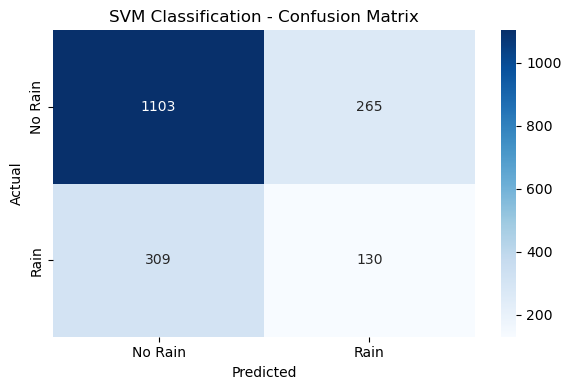

In [6]:
# Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the Confusion Matrix using Seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
plt.title('SVM Classification - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()

# Save the plot directly to the required repository folder
output_path = '../results/eda_visualizations/IT25101708_SVM_ConfusionMatrix.png'
plt.savefig(output_path, dpi=300)
print(f"Confusion Matrix successfully saved to {output_path}")

plt.show()